使用遗传算法求解TSP问题 \
路径统一用0开头，因为用不同城市开头对于闭合路径没有区别

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import re

plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 使用微软雅黑
plt.rcParams["axes.unicode_minus"] = False         # 解决负号显示问题

In [6]:
def load_data_re(file_path):
    """
    用正则表达式
    从txt文件中读取以分号分隔的城市x, y坐标, 返回城市坐标列表

    :param file_path: txt文件路径
    :return city_coords: 城市坐标列表 [(x1, y1), (x2, y2), ...]
    """
    with open(file_path, 'r') as f:
        data = f.read()

    pattern = re.compile(r'(\d+)\s+(\d+)')   # x y
    matches = pattern.findall(data)

    city_coords = []
    for city in matches:                
        x = city[0]   
        y = city[1]
        city_coords.append((float(x), float(y)))
    
    return city_coords

In [7]:
# 准备输入数据
file_path = '30城市.txt'
cities = load_data_re(file_path)
print(f'总共有{len(cities)}个城市')
print('城市坐标列表：')
print(cities)

总共有30个城市
城市坐标列表：
[(41.0, 94.0), (37.0, 84.0), (54.0, 67.0), (25.0, 62.0), (7.0, 64.0), (2.0, 99.0), (68.0, 58.0), (71.0, 44.0), (54.0, 62.0), (83.0, 69.0), (64.0, 60.0), (18.0, 54.0), (22.0, 60.0), (83.0, 46.0), (91.0, 38.0), (25.0, 38.0), (24.0, 42.0), (58.0, 69.0), (71.0, 71.0), (74.0, 78.0), (87.0, 76.0), (18.0, 40.0), (13.0, 40.0), (82.0, 7.0), (62.0, 32.0), (58.0, 35.0), (45.0, 21.0), (41.0, 26.0), (44.0, 35.0), (4.0, 50.0)]


对称TSP问题：城市A到城市B的距离=城市B到城市A的距离 

- 固定起始城市 \
对于对称TSP问题，求环路，起始城市可以直接固定，只对其他城市变动，相当于缩小搜索空间 \
而不固定起始城市，交叉、变异等操作搜索的解的多样性会出现虚高现象。\
此时，每个个体为一条可行的路径，这条路径可以不包括起始城市，只包括后续的城市，减少存储空间
- 引入随机性，扩大搜寻空间 \
交叉——顺序交叉，子代1选取父代1中某条子路径，并选用父代2中其他不重复的城市填充 \
变异——随机交换两个城市的位置
- 局部搜索最优解 \
使用2-opt方法优化路径 \
2-optimiaztion，两元素优化，该算法通过随机选取路径中两个节点并反转其路径序列生成新解 \
对于欧式TSP(城市在平面上，距离为直线)问题，最优路径一定不会形成交叉 \
而2-opt通过反转子路径，可以移除交叉 \
其数学本质是边重连 \
具体是遍历所有(i, j)组合，i城市到j城市中间作为一条子路径(包括i，j)，子路径中要有2个及以上的城市 \
将这条子路径反转，如果路径的距离变小，则说明之前存在交叉，现在接受新解，否则不接受 
- 使用精英策略 
将种群中最优秀的k个个体作为精英，直接保留到下一代种群中 \
对于种群的精英个体，使用2-opt去局部优化 \
对于种群的较差个体，引入更多随机性，扩大搜寻空间



第1轮最优适应度为: 736.8289
第2轮最优适应度为: 562.5408
第3轮最优适应度为: 470.1847
第4轮最优适应度为: 427.9818
第5轮最优适应度为: 423.7406
第6轮最优适应度为: 423.7406
第7轮最优适应度为: 423.7406
第8轮最优适应度为: 423.7406
第9轮最优适应度为: 423.7406
第10轮最优适应度为: 423.7406
第11轮最优适应度为: 423.7406
第12轮最优适应度为: 423.7406
第13轮最优适应度为: 423.7406
第14轮最优适应度为: 423.7406
第15轮最优适应度为: 423.7406
第16轮最优适应度为: 423.7406
第17轮最优适应度为: 423.7406
第18轮最优适应度为: 423.7406
第19轮最优适应度为: 423.7406
第20轮最优适应度为: 423.7406


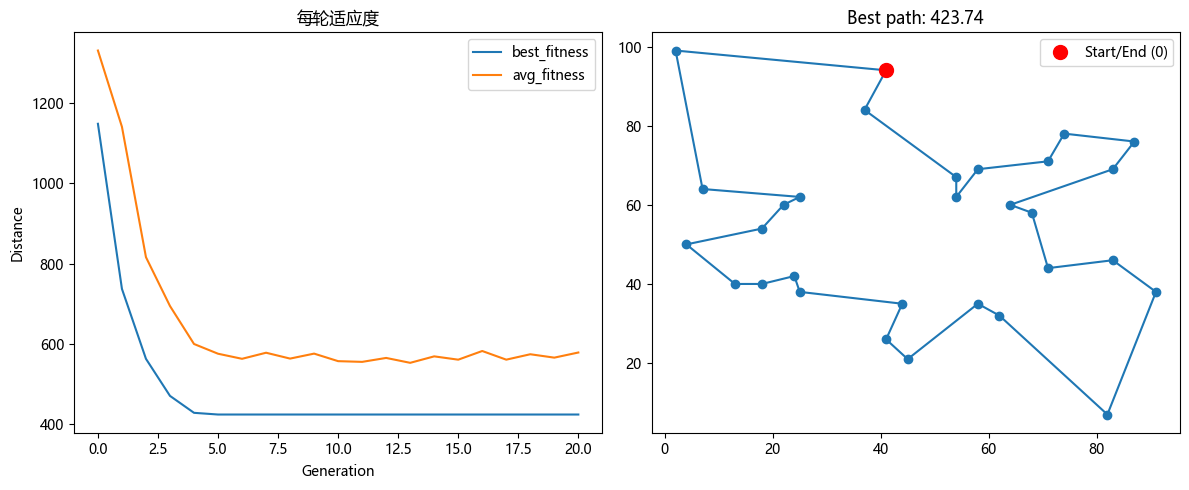

In [ ]:
class GA_TSP:
    """
    遗传算法求解TSP问题

    Attributes:
        cities: 城市坐标列表 [(x1, y1), (x2, y2), ...]
        start_city: 固定路径的起始城市的编号
        pop_size: 种群大小
        elite_size: 精英保留个数
        cross_rate: 交叉概率
        mutation_rate: 变异概率 
        generations: 迭代次数
    """
    def __init__(self, cities, start_city=0, pop_size=100, elite_size=10, cross_rate=0.8, mutation_rate=0.8, generations=2000):
        """ 
        初始化

        Args:
            cities: 城市坐标列表 [(x1, y1), (x2, y2), ...]
            start_city: 固定路径的起始城市的编号
            pop_size: 种群大小
            elite_size: 精英保留个数
            cross_rate: 交叉概率
            mutation_rate: 变异概率 
            generations: 迭代次数
        """
        # 城市信息
        self.cities = cities
        self.num_cities = len(cities)
        self.distance_matrix = self._compute_distance_matrix()
        assert 0 <= start_city < self.num_cities, "start_city out of range"
        self.start_city = start_city
        self.variable_cities = [i for i in range(self.num_cities) if i != start_city]   # 需要变动的其他城市

        # 遗传算法超参数
        self.pop_size = pop_size
        self.elite_size = elite_size
        self.cross_rate = cross_rate
        self.mutation_rate = mutation_rate
        self.generations = generations

        # 内部种群状态
        self.cur_pop = None                    # 种群
        self.cur_pop_fitness = []              # 种群每个个体的适应度 适应度(距离)越小越好

        # 记录当代最优解
        self.cur_best_path = None              # 路径
        self.cur_best_fitness = float('inf')  # 路径距离

        # 记录全局最优解
        self.best_path = self.cur_best_path                
        self.best_fitness = self.cur_best_fitness     

        # 记录种群适应度每轮变化情况
        self.best_fitness_history = []        # 种群最优适应度
        self.avg_fitness_history = []         # 种群平均适应度

    def _compute_distance_matrix(self):
        """计算城市距离矩阵"""
        n = self.num_cities
        dist_matrix = np.zeros((n, n))             # 初始化距离矩阵
        for i in range(n):                         # 对每个城市
            x1, y1 = self.cities[i]
            for j in range(n):                     # 计算与其他城市的距离
                if i != j:
                    x2, y2 = self.cities[j]
                    dist_matrix[i][j] = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        return dist_matrix
        
    def _path_distance(self, path):
        """
        计算路径距离
        Args:
            path: 去掉起始城市的路径
        Returns:
            distance: 路径距离
        """
        full_path = [self.start_city] + path
        distance = 0.0
        n = self.num_cities
        for i in range(n):
            city1 = full_path[i]
            city2 = full_path[(i + 1) % n]
            distance += self.distance_matrix[city1][city2]
        return distance

    def _two_opt_once(self, path):
        """
        对路径执行一次 2-opt 改进（支持环形，包含与起点相连的边）
        Args:
            path: 不含起点的城市排列
        Returns:
            优化后的 path(不含起点)
        """
        n = len(path)
        if n < 2:
            return path

        best_path = path[:]
        best_dist = self._path_distance(path)

        # 将 path 视为环：实际路径是 start -> path[0] -> ... -> path[-1] -> start
        # 所以可断开的位置有 n+1 个：(start, p0), (p0,p1), ..., (p_{n-1}, start)
        # 我们用索引 0 到 n 表示这些断点：
        #   断点 k 连接的是: 
        #       left = start if k==0 else path[k-1]
        #       right = path[k] if k < n else start
        # 尝试所有 (i, j) 断点对，满足 j >= i+2（至少跳过一条边）
        for i in range(n):          # i: 第一个断点 (0 到 n-1)
            for j in range(i + 2, n + 1):  # j: 第二个断点 (i+2 到 n)
                # 构造新路径：
                # - 保留 [0, i)
                # - 反转 [i, j)
                # - 保留 [j, n)
                new_path = path[:i] + path[i:j][::-1] + path[j:]
                # 特殊情况：如果 i==0 且 j==n，则整个 path 被反转
                # 这是合法的！例如 [2,4,1,3] → [3,1,4,2]
                new_dist = self._path_distance(new_path)
                if new_dist < best_dist:
                    best_dist = new_dist
                    best_path = new_path

        return best_path

    def _two_opt_full(self, path, max_iter=5):
        """
        多次应用 2-opt 直到收敛或达到最大迭代
        Args:
            path: 去掉起始城市的路径
            max_iter: 最大迭代次数
        Returns:
            current: 优化后的路径(不包括起始城市)
        """
        current = path[:]
        for _ in range(max_iter):
            improved = self._two_opt_once(current)
            if self._path_distance(improved) < self._path_distance(current):    # 如果遍历所有(i,j)对后，未发现交叉，则说明已优化完毕
                current = improved
            else:
                break
        return current

    def _create_individual(self):
        """随机产生一条可行路径"""
        ind = self.variable_cities.copy()
        random.shuffle(ind)               # 随机打乱可变城市
        return ind

    def _init_population(self):
        """初始化种群"""
        return [self._create_individual() for _ in range(self.pop_size)]

    def _selection(self):
        """
        选择
        Returns
            select_indices: 选出个体在种群中的编号
        """
        # 再按照适应度算选择概率，选出pop_size-elite_size个体
        min_fitness = np.min(self.cur_pop_fitness) 

        ad_fitness = 1 / (self.cur_pop_fitness - min_fitness + 1e-8)                   # 适应度越小越优，将适应度转换为选择概率（取倒数避免负适应度）
        
        probabilities = ad_fitness / np.sum(ad_fitness) # 每个个体的选择概率 
        # choice内部是轮盘赌算法，根据选择概率p计算累积概率
        # a 待选择元素范围
        # size 选择个数
        # replace=True 重复抽样
        selected_indices = np.random.choice(a=self.pop_size, size=(self.pop_size-self.elite_size), p=probabilities, replace=True)

        return selected_indices
    
    def _crossover(self, p1, p2):
        """
        使用 Order Crossover (OX) 生成两个子代
        Args:
            p1: 父代1
            p2: 父代2
        Returns:
            child1: 子代1
            child2: 子代2
        """
        size = len(p1)
        start, end = sorted(random.sample(range(size), 2))
        
        # --- 生成 child1: p1 提供片段，p2 提供顺序 ---
        if np.random.rand() < self.cross_rate: 
            child1 = [-1] * size
            child1[start:end] = p1[start:end]
            ptr = end
            for city in p2[end:] + p2[:end]:
                if city not in child1:
                    child1[ptr % size] = city
                    ptr += 1

        # --- 生成 child2: p2 提供片段，p1 提供顺序 ---
            child2 = [-1] * size
            child2[start:end] = p2[start:end]  # ← 注意：使用相同的 [start, end) 区间
            ptr = end
            for city in p1[end:] + p1[:end]:
                if city not in child2:
                    child2[ptr % size] = city
                    ptr += 1

            return child1, child2
        else:
            return p1.copy(), p2.copy()

    def _mutate(self, ind):
        """变异, 随机交换两个城市的位置"""
        for i in range(len(ind)):
            if random.random() < self.mutation_rate:
                j = random.randint(0, len(ind) - 1)
                ind[i], ind[j] = ind[j], ind[i]
        return ind
    
    def _evaluation(self):
        """评估种群, 更新状态变量"""

        # 计算种群每个个体的适应度
        self.cur_pop_fitness = [self._path_distance(ind) for ind in self.cur_pop]    

        # 计算当代最优解及其适应度 路径+路径距离 
        # 适应度即路径距离，越小越好
        cur_best_idx = np.argmin(self.cur_pop_fitness)       # 适应度最优个体的编号
        self.cur_best_path = self.cur_pop[cur_best_idx] 
        self.cur_best_fitness = self.cur_pop_fitness[cur_best_idx] 


        # 更新全局最优解及其适应度
        if self.cur_best_fitness < self.best_fitness:
            self.best_path = self.cur_best_path
            self.best_fitness = self.cur_best_fitness 
        
        # 记录种群适应度每轮变化情况
        self.best_fitness_history.append(self.cur_best_fitness)
        self.avg_fitness_history.append(np.mean(self.cur_pop_fitness))

    def _evolution(self):
        """
        一轮种群进化
        """
        # 精英策略 精英个体直接保留到下一轮

        # 先对种群按照适应度(路径距离)升序排序, 给出排序后的个体编号
        # 选出当代种群中最优的k个精英个体
        rank_idices = [i for i, x in sorted(enumerate(self.cur_pop_fitness), key=lambda pair: pair[1])]
        elite_indices = rank_idices[:self.elite_size]   # 取出精英个体的编号

        # 对精英个体进行 2-opt 优化
        elite = []
        for idx in elite_indices:
            original = self.cur_pop[idx]
            optimized = self._two_opt_full(original, max_iter=5)
            elite.append(optimized)

        # 选择其他个体填充种群
        select_indices = self._selection()                            
        mating_pool = [self.cur_pop[i] for i in select_indices]

        # 对选择的其他个体进行交叉、变异
        children = []
        for i in range(0, len(mating_pool), 2):    # 每两个父体交叉并变异
            parent1 = mating_pool[i]
            parent2 = mating_pool[(i + 1) % len(mating_pool)]
            # 交叉
            child1, child2 = self._crossover(parent1, parent2)
            # 变异
            child1 = self._mutate(child1)
            child2 = self._mutate(child2)

            children.append(child1)
            children.append(child2)

        self.cur_pop = elite + children[:self.pop_size - self.elite_size]

    def solve(self, plot=False):
        """运行遗传算法"""
        self.cur_pop = self._init_population()                 # 初始化种群
        self._evaluation()                                         # 更新状态变量

        for gen in range(self.generations):             # 每轮迭代
            self._evolution()                           # 种群进化(选择+交叉+变异)

            self._evaluation()
            print(f'第{gen+1}轮最优适应度为: {self.best_fitness_history[-1]:.4f}')

        if plot:
            self._plot()

    def _plot(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.plot(self.best_fitness_history, label='best_fitness')
        ax1.plot(self.avg_fitness_history, label='avg_fitness')
        ax1.set_title("每轮适应度")
        ax1.set_xlabel("Generation")
        ax1.set_ylabel("Distance")
        ax1.legend()

        start = self.start_city
        xs = [self.cities[start][0]] + [self.cities[i][0] for i in self.best_path] + [self.cities[start][0]]
        ys = [self.cities[start][1]] + [self.cities[i][1] for i in self.best_path] + [self.cities[start][1]]
        ax2.plot(xs, ys, 'o-', markersize=6)
        ax2.plot(self.cities[self.start_city][0], self.cities[self.start_city][1],
                 'ro', markersize=10, label=f'Start/End ({self.start_city})')
        ax2.legend()
        ax2.set_title(f"Best path: {self.best_fitness_history[-1]:.2f}")
        plt.tight_layout()
        plt.show()

ga = GA_TSP(
    cities=cities,
    pop_size=100,
    elite_size=10,          # 适度精英保留
    cross_rate=0.8,
    mutation_rate=0.05,     # 稍高变异率
    generations=20,
    start_city=0
)
ga.solve(plot=True)